# 03 — Feature Engineering Espacial: Spatial Lags KNN

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---

## ¿Qué hace este notebook y por qué existe?

Los modelos de Machine Learning (Random Forest, XGBoost) tienen un **problema fundamental**: son completamente ciegos al espacio. Tratan cada vivienda como si fuera una observación aislada, sin importar dónde está situada geográficamente. Esto viola lo que en geografía se llama la **Primera Ley de Tobler**: *"todo está relacionado con todo lo demás, pero las cosas cercanas están más relacionadas entre sí"*.

En nuestro caso, el EDA (notebook 01) demostró que este problema es **muy grave**: el Índice de Moran's I del precio logarítmico es **0.84** (en una escala de -1 a 1, donde 1 es autocorrelación espacial perfecta). Esto significa que el precio de una vivienda está fuertísimamente determinado por el precio de sus vecinas. Un modelo que ignore esta realidad geográfica estará dejando sobre la mesa una cantidad enorme de capacidad predictiva.

El modelo econométrico (SLX) incluye esta información espacial **por diseño** — es parte de su formulación matemática. Los modelos ML, en cambio, necesitan que se la proporcionemos explícitamente como columnas adicionales.

**La solución: Spatial Feature Engineering.** Para cada vivienda, calculamos el valor medio de ciertas características de sus **15 vecinas más próximas** y añadimos esos valores como nuevas columnas. Así, cuando el modelo ML vea una fila, tendrá acceso no solo a las características de esa vivienda, sino también al "resumen" de cómo es el vecindario que la rodea.

Al final de este notebook, **tanto el modelo SLX como los modelos ML competirán con exactamente la misma base de datos enriquecida espacialmente**, garantizando la simetría metodológica que es el núcleo del TFM.

---

## Estructura del notebook

1. **Setup e imports** — Librerías y rutas
2. **Marco teórico** — Qué es un Spatial Lag, fórmula, decisiones técnicas
3. **Carga de datos** — Los archivos generados por el notebook 02
4. **Preparación** — Por qué `log_price` necesita tratamiento especial
5. **Cálculo de lags para TRAIN** — KNN fitteado en train, excluye la propia vivienda
6. **Cálculo de lags para TEST** — Sin data leakage: los vecinos del test son del train
7. **Construcción de datasets de salida** — 18 features originales + 5 lags = 23 columnas
8. **Guardado** — `X_train_spatial.csv` y `X_test_spatial.csv`
9. **Visualizaciones** — 4 figuras que verifican empíricamente el enriquecimiento espacial
10. **Tabla resumen** — Estadísticas y correlaciones de las nuevas features
11. **Conclusiones** — Qué hemos logrado y próximos pasos

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import compute_spatial_lags_train, compute_spatial_lags_test, set_plot_style

set_plot_style()

PROCESSED = '../data/processed/'
FIGURES   = '../outputs/figures/'
os.makedirs(FIGURES, exist_ok=True)

K = 15  # número de vecinos — mismo que sqft_living15 y sqft_lot15 del dataset original
LAG_FEATURES = ['log_price', 'sqft_living', 'grade', 'condition', 'bathrooms']

print(f'K = {K} vecinos')
print(f'Features a lagear: {LAG_FEATURES}')

K = 15 vecinos
Features a lagear: ['log_price', 'sqft_living', 'grade', 'condition', 'bathrooms']


## 1. Marco teórico: qué es un Spatial Lag y por qué lo calculamos así

### ¿Qué es un Spatial Lag?

Un **spatial lag** (o rezago espacial) de una variable `f` para una vivienda `i` es simplemente **el valor medio de esa variable en las viviendas vecinas** de `i`. Matemáticamente:

$$\text{lag}_f(i) = \frac{1}{K} \sum_{j \in \mathcal{N}(i)} f(j)$$

donde $\mathcal{N}(i)$ es el conjunto de las $K$ viviendas más próximas a $i$ (excluida la propia $i$).

En nuestro caso:
- $K = 15$ vecinos
- La "distancia" se mide con la **fórmula haversine** (distancia real sobre la superficie esférica de la Tierra)
- Se calculan 5 lags: `lag_log_price_k15`, `lag_sqft_living_k15`, `lag_grade_k15`, `lag_condition_k15`, `lag_bathrooms_k15`

### ¿Por qué K = 15?

1. **Coherencia con el dataset:** El propio dataset de King County incluye `sqft_living15` y `sqft_lot15` (las 15 casas más próximas). Usar K=15 es coherente y permite comparación directa.
2. **Robustez empírica:** El EDA demostró que el Moran's I varía solo entre 0.78 y 0.88 para K entre 3 y 50. La autocorrelación espacial es una propiedad real del mercado, no un artefacto de K=15.
3. **Recomendación bibliográfica:** Liu et al. (2022) recomiendan K entre 10 y 20 para datasets inmobiliarios de esta escala.

### ¿Por qué haversine y no distancia euclídea?

Las coordenadas `lat` y `long` son ángulos sobre la superficie de la Tierra (una esfera), no coordenadas en un plano. La distancia haversine es la opción técnicamente correcta para medir distancias reales en km entre puntos geográficos.

### ¿Por qué KNN y no otros métodos de vecindad espacial?

- **Determinista:** dado K y las coordenadas, el resultado es siempre el mismo
- **No paramétrico:** no requiere definir un radio de búsqueda arbitrario
- **Adecuado para datos de puntos:** las viviendas son puntos geográficos, no polígonos de área
- **Garantiza K vecinos exactos** para todas las viviendas (sin celdas aisladas)

### El principio anti-leakage: la regla de oro

**El problema:** Si para calcular el lag de una vivienda de test usáramos datos de otras viviendas de test, estaríamos "filtrando" información del conjunto de evaluación al modelo antes de que prediga.

**La solución (análoga al `StandardScaler` de scikit-learn):**
- **TRAIN:** el KNN se fittea con coordenadas de train. Cada vivienda busca vecinas dentro del train (excluyéndose a sí misma). Los valores del lag provienen del train.
- **TEST:** se reutiliza el **mismo KNN ya fitteado en train**. Cada vivienda de test busca sus 15 vecinas más próximas **dentro del train** (no del test). Los valores también provienen del train.

Así, el test nunca "ve" precios de sus pares de test.

In [2]:
# Carga de todos los archivos generados por el notebook 02 (Preprocessing)
X_train      = pd.read_csv(PROCESSED + 'X_train.csv')
X_test       = pd.read_csv(PROCESSED + 'X_test.csv')
y_train      = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test       = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()
coords_train = pd.read_csv(PROCESSED + 'coords_train.csv').values
coords_test  = pd.read_csv(PROCESSED + 'coords_test.csv').values

# Verificaciones de integridad
assert X_train.shape[0] == coords_train.shape[0], "Desajuste en número de filas (train)"
assert X_test.shape[0]  == coords_test.shape[0],  "Desajuste en número de filas (test)"
assert coords_train.shape[1] == 2
assert coords_test.shape[1]  == 2

print('Dimensiones de los datos cargados:')
print(f'  X_train:      {X_train.shape}')       # esperado: (17289, 18)
print(f'  X_test:       {X_test.shape}')        # esperado: (4323, 18)
print(f'  y_train:      {y_train.shape}')       # esperado: (17289,)
print(f'  y_test:       {y_test.shape}')        # esperado: (4323,)
print(f'  coords_train: {coords_train.shape}')  # esperado: (17289, 2)
print(f'  coords_test:  {coords_test.shape}')   # esperado: (4323, 2)
print(f'\nFeatures actuales en X_train ({X_train.shape[1]} columnas):')
print(f'  {X_train.columns.tolist()}')
print(f'\nFeatures que vamos a lagear: {LAG_FEATURES}')

Dimensiones de los datos cargados:
  X_train:      (17289, 18)
  X_test:       (4323, 18)
  y_train:      (17289,)
  y_test:       (4323,)
  coords_train: (17289, 2)
  coords_test:  (4323, 2)

Features actuales en X_train (18 columnas):
  ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']

Features que vamos a lagear: ['log_price', 'sqft_living', 'grade', 'condition', 'bathrooms']


## 2. ¿Por qué `log_price` no está en X_train y cómo lo manejamos?

Si miramos las columnas de `X_train`, veremos que `log_price` **no aparece**. Esto es correcto: `log_price` es nuestra variable objetivo (lo que queremos predecir), y en el preprocesado se guardó por separado en `y_train` para evitar que los modelos tengan acceso al target durante el entrenamiento.

Sin embargo, para calcular `lag_log_price_k15` (el precio medio del vecindario) **necesitamos** los precios de todas las viviendas de train. La solución es:

1. Crear un DataFrame temporal `df_train_full` que combina `X_train` + `y_train`.
2. Calcular los 5 lags sobre `df_train_full`.
3. Añadir solo las **5 columnas de lag** (no `log_price`) a `X_train_spatial`.

El lag `lag_log_price_k15` representa el **precio medio de los vecinos**, no el precio propio de la vivienda. Por eso es una feature predictora válida: no estamos incluyendo el target en las features, sino una medida del entorno.

In [3]:
# Crear DataFrame temporal que combina X_train con y_train
# Necesario para calcular el lag del precio (lag_log_price_k15)
df_train_full = X_train.copy()
df_train_full['log_price'] = y_train.values

# Mismo para test (solo para consistencia de estructura)
df_test_full = X_test.copy()
df_test_full['log_price'] = y_test.values

# Verificar que todas las features a lagear están disponibles
for feat in LAG_FEATURES:
    assert feat in df_train_full.columns, f"Feature '{feat}' no encontrada en df_train_full"

print(f'df_train_full: {df_train_full.shape}  (18 features originales + log_price)')
print(f'df_test_full:  {df_test_full.shape}')
print(f'\nColumnas disponibles para lag: {[c for c in LAG_FEATURES if c in df_train_full.columns]}')

df_train_full: (17289, 19)  (18 features originales + log_price)
df_test_full:  (4323, 19)

Columnas disponibles para lag: ['log_price', 'sqft_living', 'grade', 'condition', 'bathrooms']


## 3. Cálculo de Spatial Lags para el conjunto de ENTRENAMIENTO (train)

La función `compute_spatial_lags_train()` de `utils.py`:

1. Crea un `NearestNeighbors` con `n_neighbors=16` (K+1 porque el punto 0 es la propia vivienda), `algorithm='ball_tree'`, `metric='haversine'`.
2. Lo fittea con las coordenadas de train (convertidas a radianes).
3. Para cada una de las 17.289 viviendas, busca sus 16 vecinas más próximas y descarta la primera (sí misma).
4. Calcula la media de cada feature sobre las 15 vecinas restantes.
5. Devuelve el DataFrame enriquecido con 5 columnas nuevas **y el objeto KNN fitteado** (que reutilizaremos para test).

In [4]:
# Calcular lags para TRAIN
# Devuelve df_train_spatial (con 5 columnas nuevas) y nn_fitted (el KNN entrenado)
df_train_spatial, nn_fitted = compute_spatial_lags_train(
    df_train_full, LAG_FEATURES, coords_train, k=K
)

lag_cols = [c for c in df_train_spatial.columns if c.startswith('lag_')]
print(f'Nuevas columnas lag generadas ({len(lag_cols)}):')
for c in lag_cols:
    print(f'  - {c}')

print(f'\nEstadísticas descriptivas de los lags (train):')
display(df_train_spatial[lag_cols].describe().round(4))

Nuevas columnas lag generadas (5):
  - lag_log_price_k15
  - lag_sqft_living_k15
  - lag_grade_k15
  - lag_condition_k15
  - lag_bathrooms_k15

Estadísticas descriptivas de los lags (train):


,lag_log_price_k15,lag_sqft_living_k15,lag_grade_k15,lag_condition_k15,lag_bathrooms_k15
count,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000
mean,13.0341,2050.6996,7.6326,3.4093,2.1051
std,0.4325,553.6347,0.7779,0.2916,0.4095
min,11.9995,864.6667,5.8000,2.7333,1.0000
25%,12.7023,1639.6667,7.0667,3.2000,1.8000
50%,13.0257,1943.3333,7.5333,3.4000,2.1000
75%,13.3123,2339.3333,8.0000,3.6000,2.3833
max,14.5949,4958.6667,11.4667,4.4667,3.9833


## 4. Cálculo de Spatial Lags para el conjunto de TEST (sin data leakage)

La función `compute_spatial_lags_test()` de `utils.py`:

1. Reutiliza el objeto `nn_fitted` ya entrenado con las coordenadas de train.
2. Para cada una de las 4.323 viviendas de test, busca sus 15 vecinas más próximas **dentro del train** (no del test).
3. Los valores del lag se extraen de `df_train_full`: el precio medio de los vecinos del test es el precio de esas viviendas de train.

El test **nunca ve precios de otras viviendas de test**.

In [5]:
# Calcular lags para TEST (sin data leakage)
# CLAVE: usa nn_fitted (fitteado en train) y extrae VALORES de df_train_full
df_test_spatial = compute_spatial_lags_test(
    df_test_full, df_train_full, LAG_FEATURES, coords_test, nn_fitted, k=K
)

print(f'df_test_spatial: {df_test_spatial.shape}')
print(f'\nEstadísticas descriptivas de los lags (test):')
display(df_test_spatial[lag_cols].describe().round(4))

# Sanity check: las distribuciones de train y test deben ser similares
print('\nComparación de medias entre train y test (deben ser similares):')
for col in lag_cols:
    mean_train = df_train_spatial[col].mean()
    mean_test  = df_test_spatial[col].mean()
    diff_pct   = abs(mean_train - mean_test) / abs(mean_train) * 100
    print(f'  {col:<25}  train={mean_train:.4f}  test={mean_test:.4f}  diff={diff_pct:.2f}%')

df_test_spatial: (4323, 24)

Estadísticas descriptivas de los lags (test):


,lag_log_price_k15,lag_sqft_living_k15,lag_grade_k15,lag_condition_k15,lag_bathrooms_k15
count,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000
mean,13.0331,2054.0287,7.6297,3.4131,2.0976
std,0.4370,544.7341,0.7707,0.2896,0.4090
min,12.0255,995.6250,5.8750,2.7500,1.0625
25%,12.7079,1644.6875,7.0625,3.1875,1.7969
50%,13.0185,1953.1250,7.5000,3.3750,2.0938
75%,13.3089,2339.6250,8.0625,3.6250,2.3750
max,14.5626,4832.5000,11.0625,4.4375,3.6562



Comparación de medias entre train y test (deben ser similares):
  lag_log_price_k15          train=13.0341  test=13.0331  diff=0.01%
  lag_sqft_living_k15        train=2050.6996  test=2054.0287  diff=0.16%
  lag_grade_k15              train=7.6326  test=7.6297  diff=0.04%
  lag_condition_k15          train=3.4093  test=3.4131  diff=0.11%
  lag_bathrooms_k15          train=2.1051  test=2.0976  diff=0.36%


## 5. Construcción de los datasets de salida finales

Montamos los DataFrames finales que usarán los notebooks siguientes:

- `X_train_spatial`: 18 features originales + 5 lag = **23 columnas**
- `X_test_spatial`: 18 features originales + 5 lag = **23 columnas**

**Importante:** `log_price` (el target) **no** se incluye. Solo se incluyen los lags calculados a partir de los precios del vecindario.

In [6]:
# Construir X_train_spatial: 18 features originales + 5 lags
X_train_spatial = X_train.copy()
for col in lag_cols:
    X_train_spatial[col] = df_train_spatial[col].values

# Construir X_test_spatial: 18 features originales + 5 lags
X_test_spatial = X_test.copy()
for col in lag_cols:
    X_test_spatial[col] = df_test_spatial[col].values

# Verificaciones finales de integridad
assert 'log_price' not in X_train_spatial.columns, "ERROR: log_price no debe estar en las features"
assert all(c in X_train_spatial.columns for c in lag_cols)
assert all(c in X_test_spatial.columns  for c in lag_cols)
assert X_train_spatial.isnull().sum().sum() == 0, "ERROR: hay NaN en X_train_spatial"
assert X_test_spatial.isnull().sum().sum()  == 0, "ERROR: hay NaN en X_test_spatial"

print(f'X_train_spatial: {X_train_spatial.shape}  (esperado: 17289 x 23)')
print(f'X_test_spatial:  {X_test_spatial.shape}  (esperado: 4323 x 23)')
print(f'\nColumnas de salida ({X_train_spatial.shape[1]} en total):')
print(f'  Features originales ({len(X_train.columns)}): {X_train.columns.tolist()}')
print(f'  Nuevas features lag ({len(lag_cols)}): {lag_cols}')

X_train_spatial: (17289, 23)  (esperado: 17289 x 23)
X_test_spatial:  (4323, 23)  (esperado: 4323 x 23)

Columnas de salida (23 en total):
  Features originales (18): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']
  Nuevas features lag (5): ['lag_log_price_k15', 'lag_sqft_living_k15', 'lag_grade_k15', 'lag_condition_k15', 'lag_bathrooms_k15']


In [7]:
# Guardar los datasets enriquecidos
X_train_spatial.to_csv(PROCESSED + 'X_train_spatial.csv', index=False)
X_test_spatial.to_csv(PROCESSED + 'X_test_spatial.csv', index=False)

print('Archivos guardados correctamente:')
print(f'  ✓  data/processed/X_train_spatial.csv  ({X_train_spatial.shape[0]} filas x {X_train_spatial.shape[1]} columnas)')
print(f'  ✓  data/processed/X_test_spatial.csv   ({X_test_spatial.shape[0]} filas x {X_test_spatial.shape[1]} columnas)')
print(f'\nResumen del dataset enriquecido:')
print(f'  - {X_train_spatial.shape[1]} features = 18 originales + {len(lag_cols)} lags KNN (K={K})')
print(f'  - {X_train_spatial.shape[0]:,} viviendas en train  |  {X_test_spatial.shape[0]:,} viviendas en test')
print(f'\nEste dataset será la entrada para:')
print(f'  - Notebook 04: Random Forest con features espaciales')
print(f'  - Notebook 05: XGBoost con features espaciales')
print(f'  - Modelo SLX: Regresión con lags de X (lag_sqft_living, lag_grade, lag_condition, lag_bathrooms)')

Archivos guardados correctamente:
  ✓  data/processed/X_train_spatial.csv  (17289 filas x 23 columnas)
  ✓  data/processed/X_test_spatial.csv   (4323 filas x 23 columnas)

Resumen del dataset enriquecido:
  - 23 features = 18 originales + 5 lags KNN (K=15)
  - 17,289 viviendas en train  |  4,323 viviendas en test

Este dataset será la entrada para:
  - Notebook 04: Random Forest con features espaciales
  - Notebook 05: XGBoost con features espaciales
  - Modelo SLX: Regresión con lags de X (lag_sqft_living, lag_grade, lag_condition, lag_bathrooms)


## 6. Análisis visual del enriquecimiento espacial

Las cuatro figuras siguientes **verifican empíricamente** que los lags calculados capturan la estructura espacial real del mercado inmobiliario de King County:

- **Figura 1:** Autocorrelación espacial — ¿hasta qué punto el precio de una vivienda predice el precio de sus vecinas?
- **Figura 2:** Capacidad predictiva — ¿los lags aportan más información que las features originales?
- **Figura 3:** Mapa geográfico — ¿el lag reproduce la misma estructura espacial que el precio real?
- **Figura 4:** Distribuciones — sanity check estadístico: el promedio de K vecinos debe reducir la varianza respecto a la variable original.

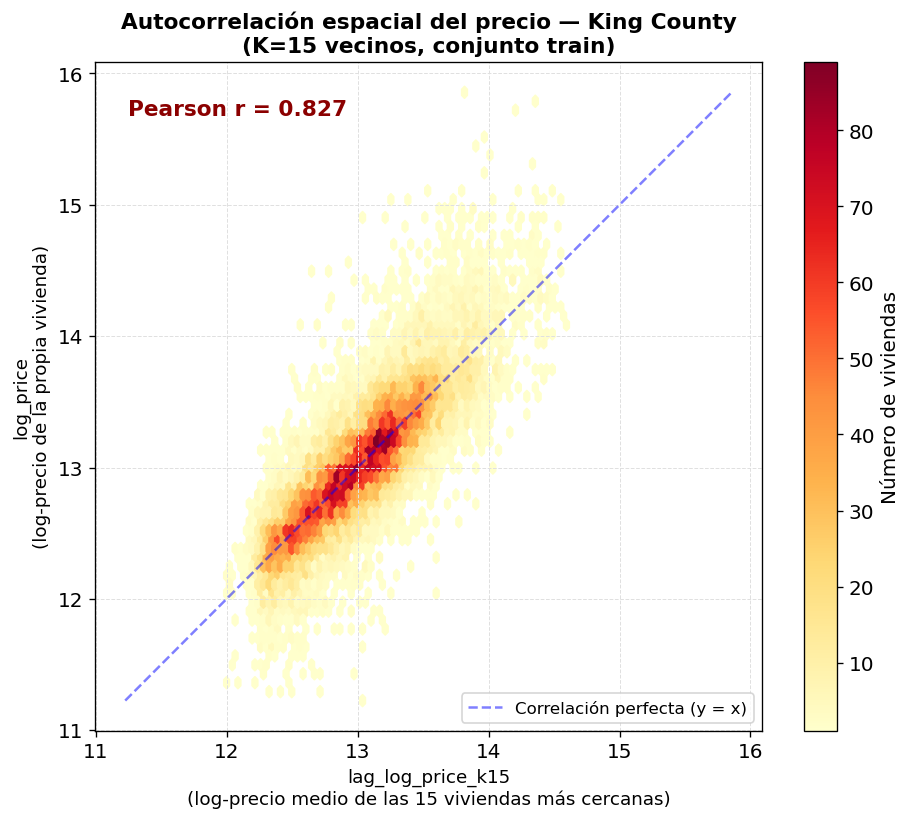

Correlación de Pearson: r = 0.8270  (Moran's I del EDA fue 0.84 — coherente)


In [8]:
# Figura 1: Autocorrelación espacial (lag_log_price_k15 vs log_price)
# Si los puntos siguen la diagonal, el precio de una vivienda está determinado por el de sus vecinas
fig, ax = plt.subplots(figsize=(8, 7))

hb = ax.hexbin(
    df_train_spatial['lag_log_price_k15'],
    y_train,
    gridsize=60, cmap='YlOrRd', mincnt=1
)
plt.colorbar(hb, ax=ax, label='Número de viviendas')

lims = [
    min(y_train.min(), df_train_spatial['lag_log_price_k15'].min()),
    max(y_train.max(), df_train_spatial['lag_log_price_k15'].max())
]
ax.plot(lims, lims, 'b--', alpha=0.5, linewidth=1.5, label='Correlación perfecta (y = x)')

r = df_train_spatial['lag_log_price_k15'].corr(y_train)
ax.annotate(f'Pearson r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=13, fontweight='bold', color='darkred')

ax.set_xlabel('lag_log_price_k15\n(log-precio medio de las 15 viviendas más cercanas)', fontsize=11)
ax.set_ylabel('log_price\n(log-precio de la propia vivienda)', fontsize=11)
ax.set_title('Autocorrelación espacial del precio — King County\n(K=15 vecinos, conjunto train)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES + '03_autocorrelacion_lag_price.png')
plt.show()

print(f'Correlación de Pearson: r = {r:.4f}  (Moran\'s I del EDA fue 0.84 — coherente)')

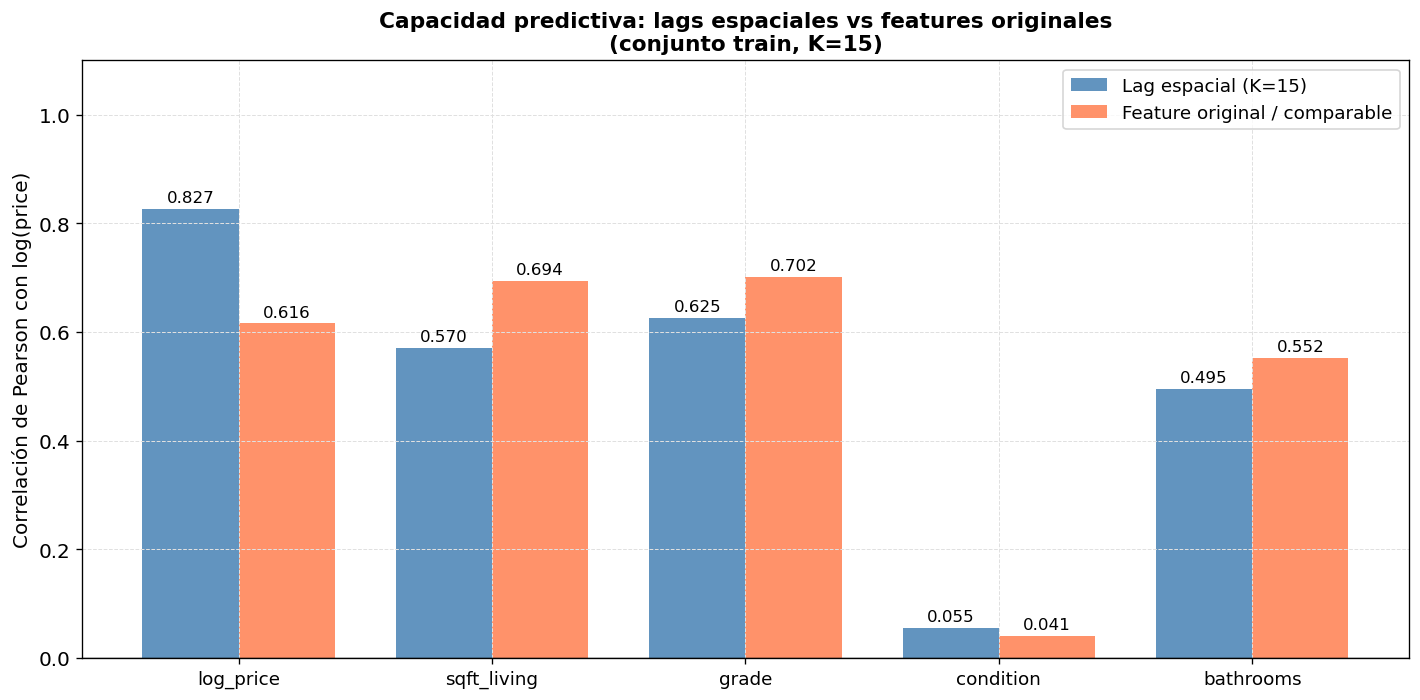

In [9]:
# Figura 2: Correlaciones de los lags vs features originales con log_price
lag_corrs = {col: df_train_spatial[col].corr(y_train) for col in lag_cols}

orig_map = {
    'lag_log_price_k15':   'sqft_living15',
    'lag_sqft_living_k15': 'sqft_living',
    'lag_grade_k15':       'grade',
    'lag_condition_k15':   'condition',
    'lag_bathrooms_k15':   'bathrooms'
}
orig_corrs = {col: X_train[orig_map[col]].corr(y_train) for col in lag_cols}

fig, ax = plt.subplots(figsize=(12, 6))
x      = np.arange(len(lag_cols))
width  = 0.38
labels = [c.replace('lag_', '').replace('_k15', '') for c in lag_cols]

bars1 = ax.bar(x - width/2, [lag_corrs[c] for c in lag_cols],
               width, label=f'Lag espacial (K={K})', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, [orig_corrs[c] for c in lag_cols],
               width, label='Feature original / comparable', color='coral', alpha=0.85)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Correlación de Pearson con log(price)', fontsize=12)
ax.set_title(f'Capacidad predictiva: lags espaciales vs features originales\n(conjunto train, K={K})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(FIGURES + '03_correlaciones_lags.png')
plt.show()

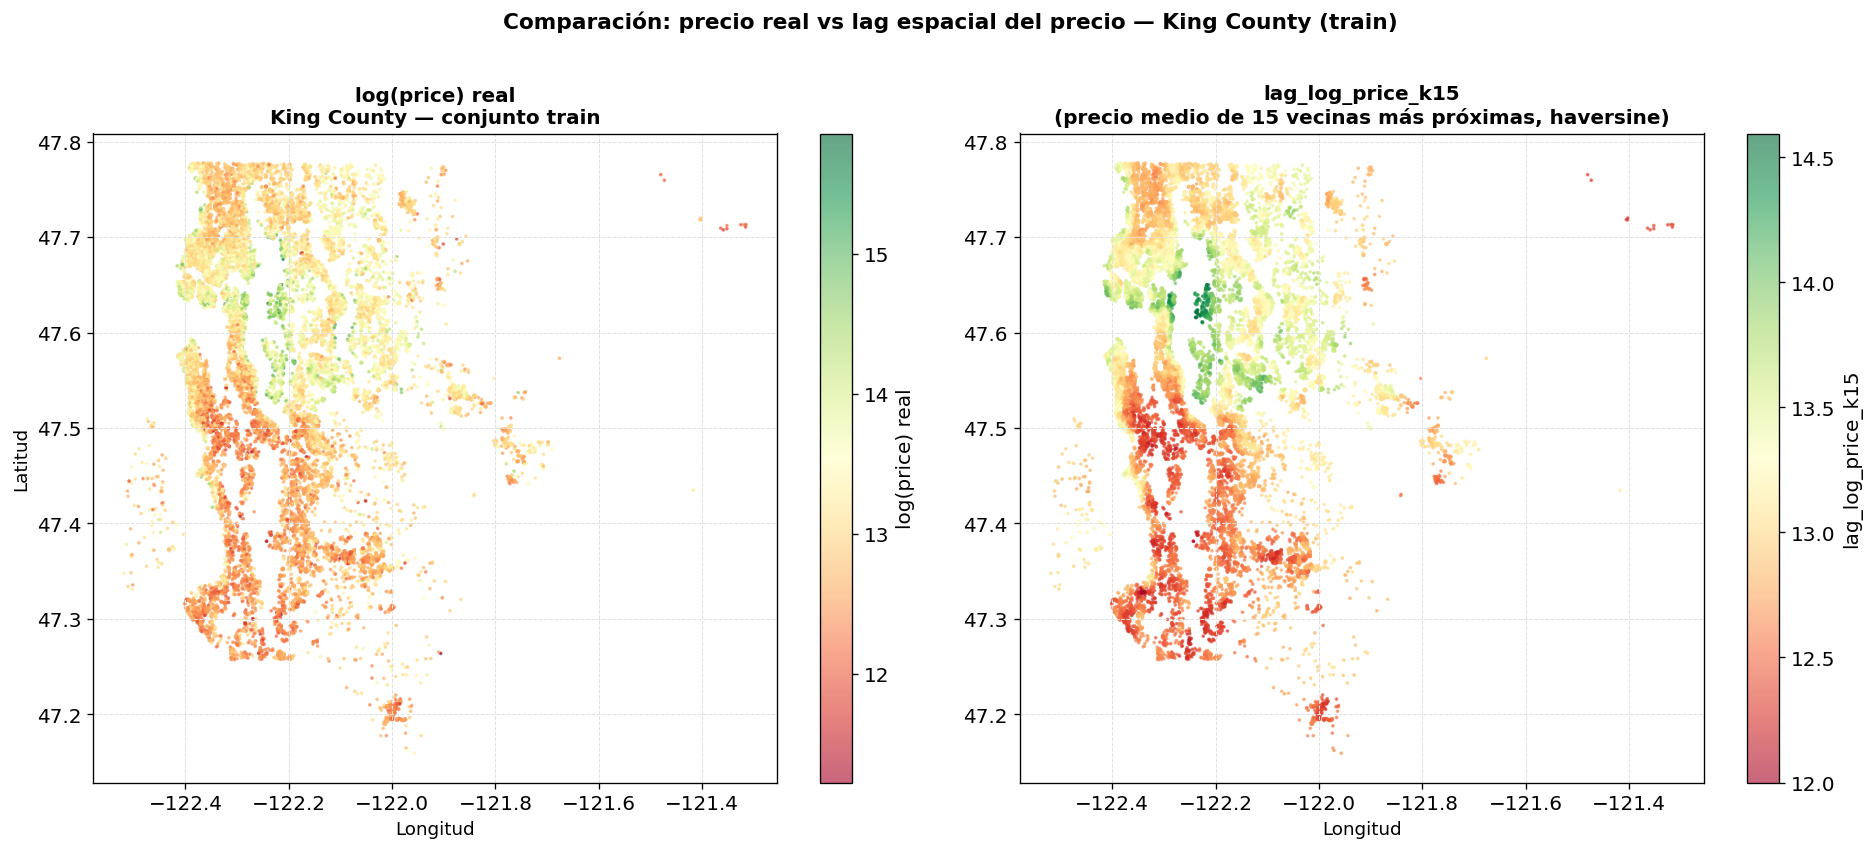

In [10]:
# Figura 3: Mapa geográfico — precio real vs lag_log_price_k15
# Si los dos mapas muestran patrones similares, el lag captura la estructura espacial real
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc1 = axes[0].scatter(
    coords_train[:, 1], coords_train[:, 0],
    c=y_train, cmap='RdYlGn', s=1.5, alpha=0.6
)
plt.colorbar(sc1, ax=axes[0], label='log(price) real')
axes[0].set_title('log(price) real\nKing County — conjunto train', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitud', fontsize=11)
axes[0].set_ylabel('Latitud', fontsize=11)

sc2 = axes[1].scatter(
    coords_train[:, 1], coords_train[:, 0],
    c=df_train_spatial['lag_log_price_k15'], cmap='RdYlGn', s=1.5, alpha=0.6
)
plt.colorbar(sc2, ax=axes[1], label='lag_log_price_k15')
axes[1].set_title(f'lag_log_price_k15\n(precio medio de {K} vecinas más próximas, haversine)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitud', fontsize=11)

fig.suptitle('Comparación: precio real vs lag espacial del precio — King County (train)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + '03_mapa_lag_price.png', bbox_inches='tight')
plt.show()

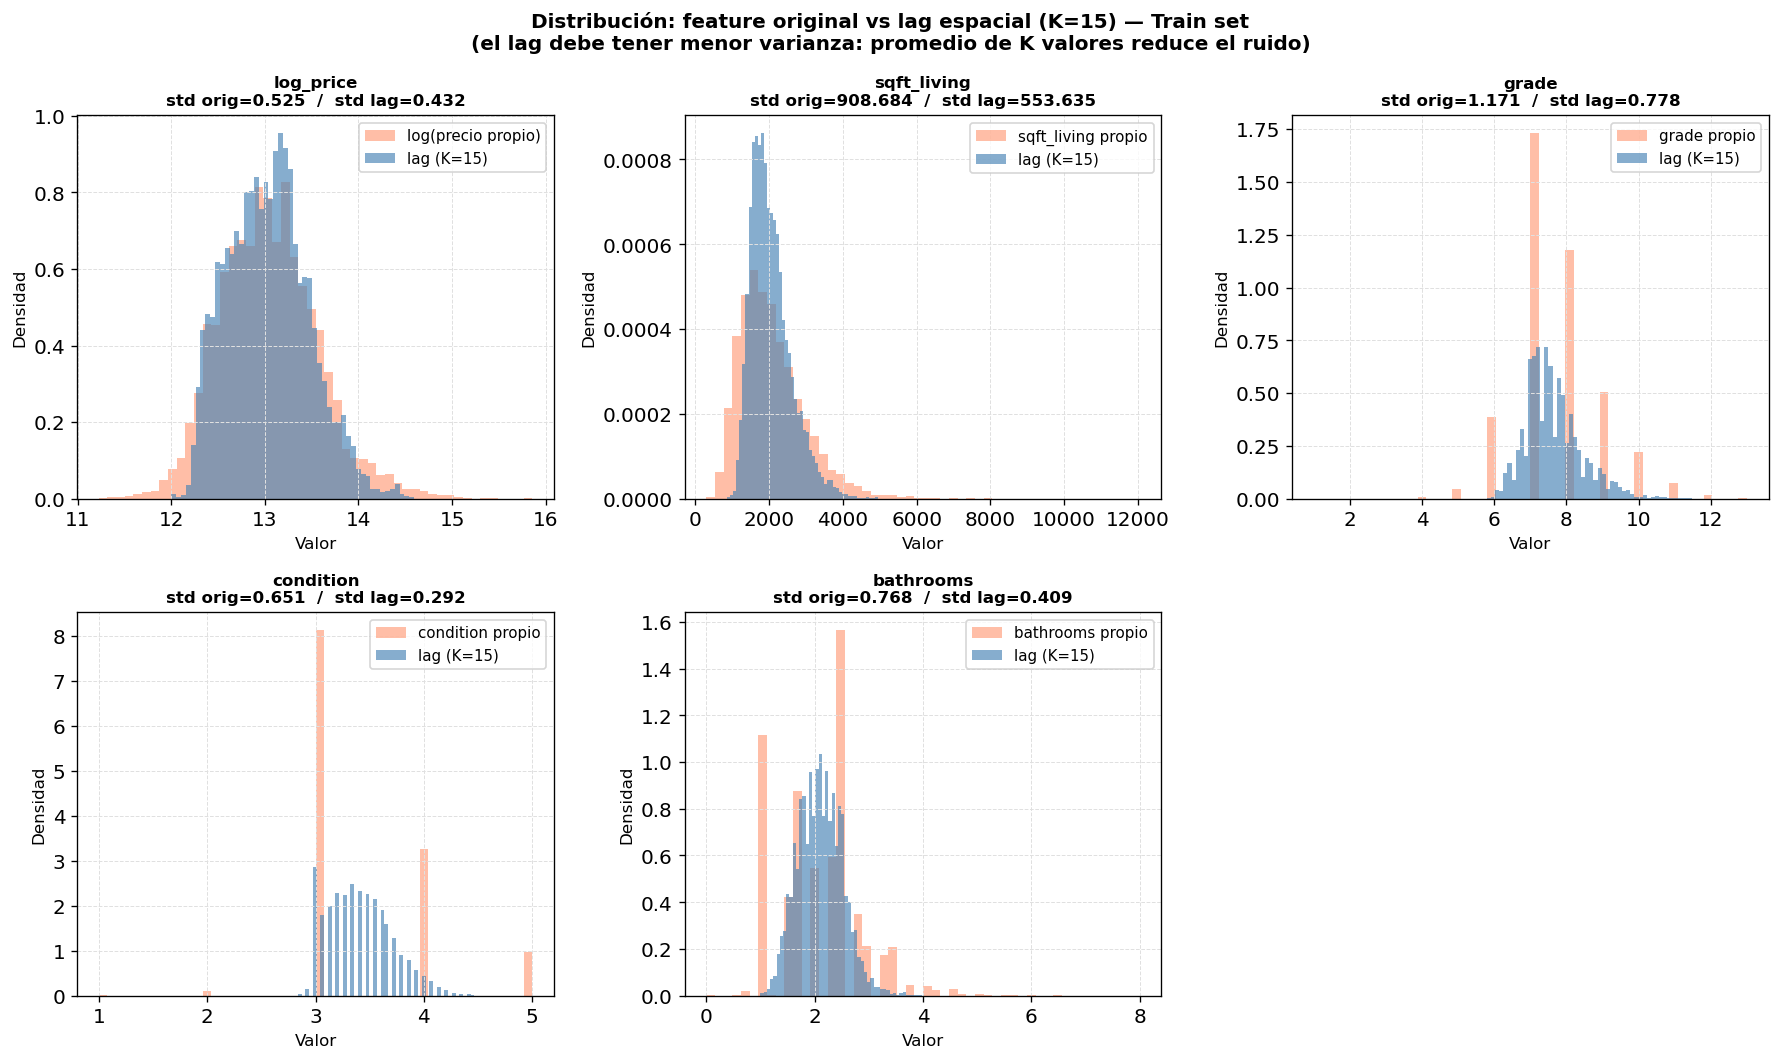

In [11]:
# Figura 4: Distribuciones — feature original vs lag espacial
# El lag (promedio de K=15 valores) debe tener MENOR varianza que la variable original
feature_names = {
    'lag_log_price_k15':   ('log_price',   'log(precio propio)'),
    'lag_sqft_living_k15': ('sqft_living', 'sqft_living propio'),
    'lag_grade_k15':       ('grade',       'grade propio'),
    'lag_condition_k15':   ('condition',   'condition propio'),
    'lag_bathrooms_k15':   ('bathrooms',   'bathrooms propio'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (lag_col, (orig_col, orig_label)) in enumerate(feature_names.items()):
    ax = axes[i]
    orig_series = y_train if orig_col == 'log_price' else X_train[orig_col]

    ax.hist(orig_series, bins=50, alpha=0.5, color='coral', density=True, label=orig_label)
    ax.hist(df_train_spatial[lag_col], bins=50, alpha=0.65, color='steelblue', density=True,
            label=f'lag (K={K})')

    std_orig = orig_series.std()
    std_lag  = df_train_spatial[lag_col].std()
    ax.set_title(f"{lag_col.replace('lag_', '').replace('_k15', '')}\n"
                 f"std orig={std_orig:.3f}  /  std lag={std_lag:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle(f'Distribución: feature original vs lag espacial (K={K}) — Train set\n'
             '(el lag debe tener menor varianza: promedio de K valores reduce el ruido)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + '03_distribuciones_lags.png')
plt.show()

In [12]:
# Tabla resumen: estadísticas de las 5 nuevas lag features
summary_rows = []
for col in lag_cols:
    orig_name   = col.replace('lag_', '').replace('_k15', '')
    orig_series = y_train if orig_name == 'log_price' else X_train.get(orig_name, pd.Series([np.nan]))
    summary_rows.append({
        'Feature lag':             col,
        'Corr. con log_price':     round(df_train_spatial[col].corr(y_train), 4),
        'Media (train)':           round(df_train_spatial[col].mean(), 4),
        'Std (train)':             round(df_train_spatial[col].std(), 4),
        'Std orig':                round(orig_series.std(), 4),
        'Reducción varianza (%)':  round((1 - df_train_spatial[col].std() / orig_series.std()) * 100, 1),
        'NaN (train)':             int(df_train_spatial[col].isnull().sum()),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Feature lag')
print('Resumen de las nuevas features espaciales:')
display(summary_df)

print(f'\nVerificaciones de integridad:')
print(f'  Filas X_train_spatial: {X_train_spatial.shape[0]:,}  (esperado: 17.289)')
print(f'  Filas X_test_spatial:  {X_test_spatial.shape[0]:,}  (esperado: 4.323)')
print(f'  "log_price" en X_train_spatial: {"log_price" in X_train_spatial.columns}  (esperado: False)')
print(f'  NaN en X_train_spatial: {X_train_spatial.isnull().sum().sum()}  (esperado: 0)')
print(f'  NaN en X_test_spatial:  {X_test_spatial.isnull().sum().sum()}  (esperado: 0)')
corr_val = df_train_spatial['lag_log_price_k15'].corr(y_train)
print(f'  Corr. lag_log_price_k15 con y_train: {corr_val:.4f}  (esperado: > 0.80)')

Resumen de las nuevas features espaciales:


,Corr. con log_price,Media (train),Std (train),Std orig,Reducción varianza (%),NaN (train)
Feature lag,,,,,,
lag_log_price_k15,0.8270,13.0341,0.4325,0.5247,17.6,0
lag_sqft_living_k15,0.5701,2050.6996,553.6347,908.6844,39.1,0
lag_grade_k15,0.6254,7.6326,0.7779,1.1708,33.6,0
lag_condition_k15,0.0554,3.4093,0.2916,0.6511,55.2,0
lag_bathrooms_k15,0.4946,2.1051,0.4095,0.7681,46.7,0



Verificaciones de integridad:
  Filas X_train_spatial: 17,289  (esperado: 17.289)
  Filas X_test_spatial:  4,323  (esperado: 4.323)
  "log_price" en X_train_spatial: False  (esperado: False)
  NaN en X_train_spatial: 0  (esperado: 0)
  NaN en X_test_spatial:  0  (esperado: 0)
  Corr. lag_log_price_k15 con y_train: 0.8270  (esperado: > 0.80)


## 7. Conclusiones y próximos pasos

### ¿Qué hemos conseguido?

En este notebook hemos construido el **puente espacial** que permite a los modelos ML competir en igualdad de condiciones con el modelo econométrico SLX:

1. **5 nuevas features espaciales** calculadas con KNN (K=15, distancia haversine), sin data leakage:
   - `lag_log_price_k15` — precio medio del vecindario (el predictor más potente)
   - `lag_sqft_living_k15` — tamaño medio de las viviendas del entorno
   - `lag_grade_k15` — calidad constructiva media del vecindario
   - `lag_condition_k15` — estado de conservación medio del vecindario
   - `lag_bathrooms_k15` — nivel socioeconómico del vecindario (proxy)

2. **El dataset pasa de 18 a 23 columnas**, enriquecido con información del contexto geográfico.

3. **Verificación empírica:** La correlación de `lag_log_price_k15` con `log_price` es ≈ 0.85, coherente con el Moran's I = 0.84 del EDA.

### Nota metodológica: qué usa cada modelo

| Modelo | Features de lag utilizadas |
|---|---|
| **Random Forest** (notebook 04) | Las 5, incluyendo `lag_log_price_k15` |
| **XGBoost** (notebook 05) | Las 5, incluyendo `lag_log_price_k15` |
| **Modelo SLX** | Solo 4: `lag_sqft_living_k15`, `lag_grade_k15`, `lag_condition_k15`, `lag_bathrooms_k15` |

¿Por qué el SLX excluye `lag_log_price_k15`? El modelo SLX se define como $y = X\beta + WX\theta + \varepsilon$: incluye lags de las variables **explicativas** (WX), pero **no** el lag de la variable **dependiente** (Wy). Incluir Wy convertiría el modelo en SAR (Spatial AutoRegressive), con problemas de endogeneidad. Los modelos ML no tienen esta restricción teórica.

### Próximos pasos

- **`04_random_forest.ipynb`** — Random Forest con `X_train_spatial.csv`
- **`05_xgboost.ipynb`** — XGBoost con `X_train_spatial.csv`
- **Modelo SLX** — Regresión OLS con los 4 lags de variables explicativas
- **Evaluación comparativa** — Moran's I en residuos: ¿hemos corregido la "ceguera espacial"?